# ML Based Attendance Certification System

This notebook performs attendance preprocessing, feature engineering, exploratory data analysis, certification generation, and machine learning model training for 980 students across 40 sessions.


## Step 1: Import Required Libraries

Load all libraries needed for data processing, visualization, and machine learning.


In [4]:
# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report


## Step 2: Load Excel Workbook

In [5]:
# Load workbook and inspect available sheets
FILE_PATH = "../Dataset/ML_Attendance_Project_Dataset_980_Students_40_Sessions.xlsx"

xls = pd.ExcelFile(FILE_PATH)

print('Total Sheets :', len(xls.sheet_names))
print(xls.sheet_names[:10])


Total Sheets : 41
['Student_Master', 'Session_01', 'Session_02', 'Session_03', 'Session_04', 'Session_05', 'Session_06', 'Session_07', 'Session_08', 'Session_09']


In [6]:
# Load master student data
student_master = pd.read_excel(FILE_PATH,
                               sheet_name='Student_Master')

print(student_master.shape)
student_master.head()


(980, 3)


,Student_ID,Student_Name,Email
0,ML0001,Student_0001,student0001@gmail.com
1,ML0002,Student_0002,student0002@gmail.com
2,ML0003,Student_0003,student0003@gmail.com
3,ML0004,Student_0004,student0004@gmail.com
4,ML0005,Student_0005,student0005@gmail.com


## Step 3: Load Attendance Sessions

In [7]:
# Read all session sheets into a dictionary
session_sheets = [s for s in xls.sheet_names
                  if s.startswith('Session_')]

sessions = {}

for sheet in session_sheets:
    sessions[sheet] = pd.read_excel(FILE_PATH,
                                    sheet_name=sheet)

print('Sessions Loaded :', len(sessions))


Sessions Loaded : 40


## Step 4: Data Cleaning

Tasks performed:
- Remove duplicates
- Fill missing emails
- Standardize names
- Handle attendance outliers
- Create Present flag


In [8]:
# Function for cleaning individual session sheets
def clean_session(df):

    df = df.copy()

    df = df.drop_duplicates()

    email_map = dict(
        zip(student_master['Student_ID'],
            student_master['Email'])
    )

    df['Email'] = df.apply(
        lambda x: email_map.get(x['Student_ID'])
        if pd.isna(x['Email'])
        else x['Email'],
        axis=1
    )

    df['Student_Name'] = (
        df['Student_Name']
        .astype(str)
        .str.title()
        .str.strip()
    )

    df['Attendance_Minutes'] = (
        df['Attendance_Minutes']
        .clip(lower=0,
              upper=120)
    )

    # Student considered present if attendance >= 90 min
    df['Present'] = np.where(
        df['Attendance_Minutes'] >= 90,
        1,
        0
    )

    return df


In [9]:
# Apply cleaning to all session sheets
cleaned_sessions = {}

for session_name, df in sessions.items():
    cleaned_sessions[session_name] = clean_session(df)

print('Cleaning Completed')


Cleaning Completed


## Step 5: Create Attendance Matrix

In [10]:
# Merge all sessions into one student-level dataset
attendance_matrix = student_master.copy()

for session_name, df in cleaned_sessions.items():

    temp = df[['Student_ID', 'Present']]

    session_id = session_name.split('_')[1]

    temp = temp.rename(
        columns={'Present': f'S{session_id}'}
    )

    attendance_matrix = attendance_matrix.merge(
        temp,
        on='Student_ID',
        how='left'
    )

attendance_matrix.fillna(0,
                         inplace=True)

attendance_matrix.head()


,Student_ID,Student_Name,Email,S01,S02,S03,S04,S05,S06,S07,...,S31,S32,S33,S34,S35,S36,S37,S38,S39,S40
0,ML0001,Student_0001,student0001@gmail.com,1,1,1,1,1,1,1,...,1,1,1,1,1,1,1,1,1,1
1,ML0002,Student_0002,student0002@gmail.com,1,1,1,1,1,1,0,...,1,1,1,1,1,1,1,0,1,1
2,ML0003,Student_0003,student0003@gmail.com,1,0,1,1,0,1,1,...,1,1,1,1,1,1,1,1,0,1
3,ML0004,Student_0004,student0004@gmail.com,1,1,1,1,1,1,1,...,1,1,1,1,1,1,1,1,0,1
4,ML0005,Student_0005,student0005@gmail.com,1,1,1,1,1,1,1,...,1,1,1,1,1,1,1,1,1,1


## Step 6: Feature Engineering

In [11]:
# Calculate attendance statistics
session_cols = [
    col for col in attendance_matrix.columns
    if col.startswith('S') and col[1:].isdigit()
]
attendance_matrix['Sessions_Attended'] = (
    attendance_matrix[session_cols]
    .sum(axis=1)
)

attendance_matrix['Attendance_Rate'] = (
    attendance_matrix['Sessions_Attended'] / 40
) * 100

attendance_matrix['Missed_Sessions'] = (
    40 - attendance_matrix['Sessions_Attended']
)

attendance_matrix['Consistency'] = (
    attendance_matrix[session_cols]
    .std(axis=1)
)

attendance_matrix.head()


,Student_ID,Student_Name,Email,S01,S02,S03,S04,S05,S06,S07,...,S35,S36,S37,S38,S39,S40,Sessions_Attended,Attendance_Rate,Missed_Sessions,Consistency
0,ML0001,Student_0001,student0001@gmail.com,1,1,1,1,1,1,1,...,1,1,1,1,1,1,37,92.5,3,0.266747
1,ML0002,Student_0002,student0002@gmail.com,1,1,1,1,1,1,0,...,1,1,1,0,1,1,38,95.0,2,0.220721
2,ML0003,Student_0003,student0003@gmail.com,1,0,1,1,0,1,1,...,1,1,1,1,0,1,36,90.0,4,0.303822
3,ML0004,Student_0004,student0004@gmail.com,1,1,1,1,1,1,1,...,1,1,1,1,0,1,39,97.5,1,0.158114
4,ML0005,Student_0005,student0005@gmail.com,1,1,1,1,1,1,1,...,1,1,1,1,1,1,40,100.0,0,0.000000


## Step 7: Exploratory Data Analysis (EDA)

In [12]:
# Summary statistics
attendance_matrix[
    ['Sessions_Attended',
     'Attendance_Rate']
].describe()


,Sessions_Attended,Attendance_Rate
count,980.000000,980.000000
mean,30.416327,76.040816
std,8.820659,22.051647
min,0.000000,0.000000
25%,26.000000,65.000000
50%,33.000000,82.500000
75%,37.000000,92.500000
max,40.000000,100.000000


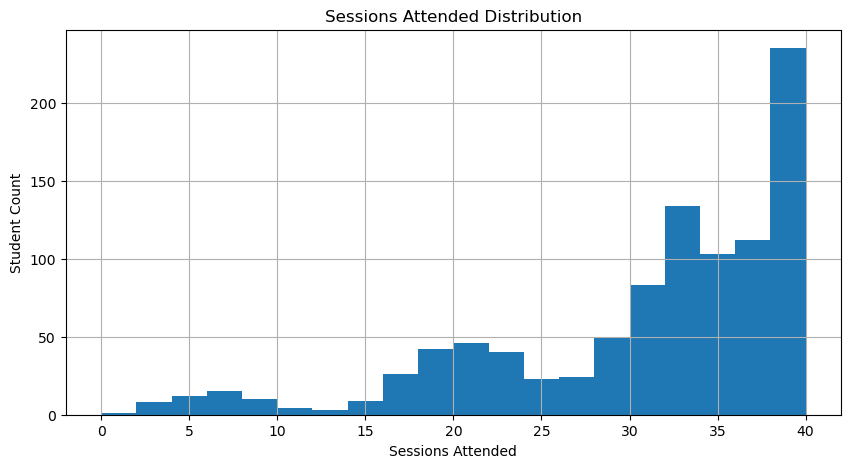

In [13]:
# Distribution of attendance
plt.figure(figsize=(10,5))

attendance_matrix['Sessions_Attended'].hist(
    bins=20
)

plt.title('Sessions Attended Distribution')
plt.xlabel('Sessions Attended')
plt.ylabel('Student Count')
plt.show()


## Step 8: Certification Generation

Certification Criteria:
- Total Sessions = 40
- Required Attendance = 80%
- Minimum Sessions Required = 32


In [14]:
# Generate certification label
attendance_matrix['Certified'] = np.where(
    attendance_matrix['Sessions_Attended'] >= 32,
    1,
    0
)

attendance_matrix[
    ['Student_ID',
     'Sessions_Attended',
     'Certified']
].head()


,Student_ID,Sessions_Attended,Certified
0,ML0001,37,1
1,ML0002,38,1
2,ML0003,36,1
3,ML0004,39,1
4,ML0005,40,1


In [15]:
# Certification statistics
attendance_matrix['Certified'].value_counts()


Certified
1    584
0    396
Name: count, dtype: int64

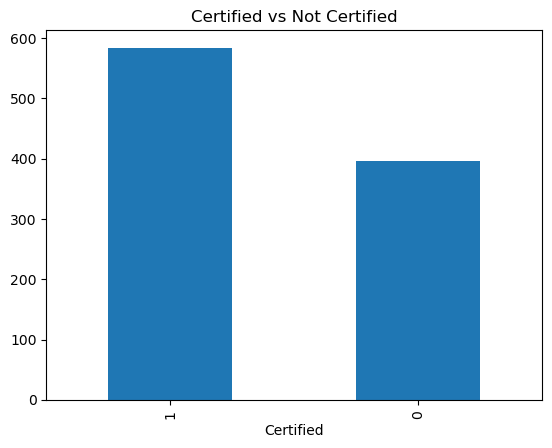

In [16]:
# Visualize certification outcome
attendance_matrix['Certified']     .value_counts()     .plot(kind='bar')

plt.title('Certified vs Not Certified')
plt.show()


## Step 9: Correlation and Pattern Analysis

In [17]:
# Examine feature relationships
numeric_cols = [
    'Sessions_Attended',
    'Attendance_Rate',
    'Missed_Sessions',
    'Consistency',
    'Certified'
]

attendance_matrix[numeric_cols].corr()


,Sessions_Attended,Attendance_Rate,Missed_Sessions,Consistency,Certified
Sessions_Attended,1.000000,1.000000,-1.000000,-0.64787,0.793896
Attendance_Rate,1.000000,1.000000,-1.000000,-0.64787,0.793896
Missed_Sessions,-1.000000,-1.000000,1.000000,0.64787,-0.793896
Consistency,-0.647870,-0.647870,0.647870,1.00000,-0.701650
Certified,0.793896,0.793896,-0.793896,-0.70165,1.000000


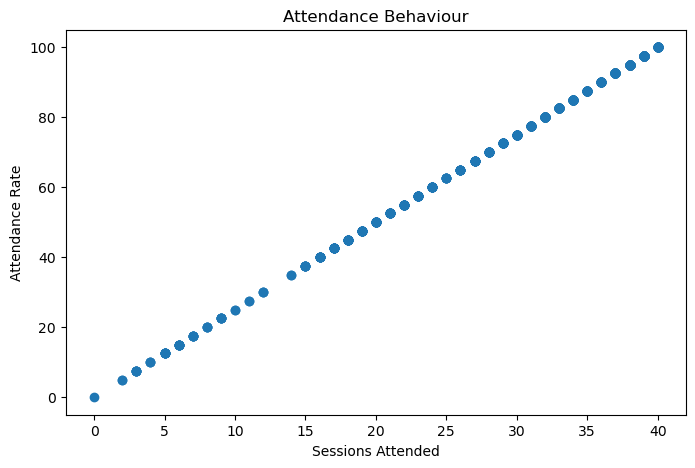

In [18]:
# Attendance trend visualization
plt.figure(figsize=(8,5))

plt.scatter(
    attendance_matrix['Sessions_Attended'],
    attendance_matrix['Attendance_Rate']
)

plt.xlabel('Sessions Attended')
plt.ylabel('Attendance Rate')
plt.title('Attendance Behaviour')

plt.show()


## Step 10: Prepare Data for Machine Learning

In [19]:
# Select features and target variable
X = attendance_matrix[[
    'Sessions_Attended',
    'Attendance_Rate',
    'Missed_Sessions',
    'Consistency'
]]

y = attendance_matrix['Certified']

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)


## Step 11: Logistic Regression

In [20]:
# Train Logistic Regression model
lr = LogisticRegression(max_iter=1000)

lr.fit(X_train, y_train)

lr_pred = lr.predict(X_test)

lr_acc = accuracy_score(y_test,
                        lr_pred)

print('Accuracy :', lr_acc)


Accuracy : 1.0


## Step 12: Decision Tree

In [21]:
# Train Decision Tree model
dt = DecisionTreeClassifier(
    random_state=42
)

dt.fit(X_train, y_train)

dt_pred = dt.predict(X_test)

dt_acc = accuracy_score(y_test,
                        dt_pred)

print('Accuracy :', dt_acc)


Accuracy : 1.0


## Step 13: Random Forest

In [22]:
# Train Random Forest model
rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)

rf_acc = accuracy_score(y_test,
                        rf_pred)

print('Accuracy :', rf_acc)


Accuracy : 1.0


## Step 14: Model Comparison

In [23]:
# Compare all model performances
results = pd.DataFrame({

    'Model': [
        'Logistic Regression',
        'Decision Tree',
        'Random Forest'
    ],

    'Accuracy': [
        lr_acc,
        dt_acc,
        rf_acc
    ]
})

results.sort_values(
    by='Accuracy',
    ascending=False
)


,Model,Accuracy
0,Logistic Regression,1.0
1,Decision Tree,1.0
2,Random Forest,1.0


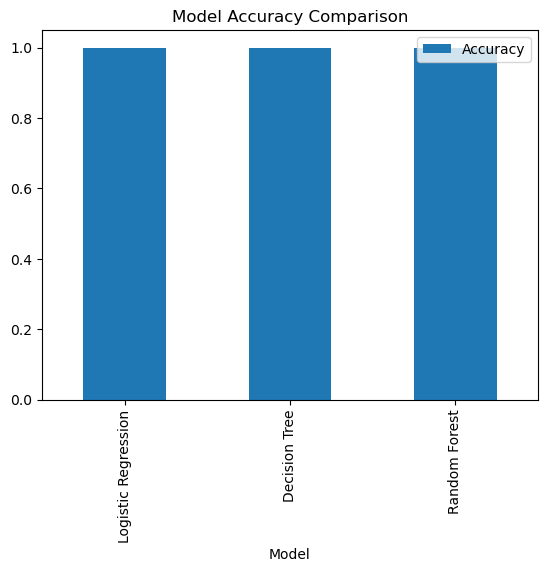

In [24]:
# Plot model comparison
results.plot(
    x='Model',
    y='Accuracy',
    kind='bar'
)

plt.title('Model Accuracy Comparison')
plt.show()


## Step 15: Confusion Matrix and Classification Report

In [25]:
# Evaluate best model
print(confusion_matrix(
    y_test,
    rf_pred
))

print(classification_report(
    y_test,
    rf_pred
))


[[ 79   0]
 [  0 117]]
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        79
           1       1.00      1.00      1.00       117

    accuracy                           1.00       196
   macro avg       1.00      1.00      1.00       196
weighted avg       1.00      1.00      1.00       196



## Step 16: Export Certified Students

In [26]:
# Create final attendance summary

attendance_matrix['Certification_Status'] = np.where(
    attendance_matrix['Certified'] == 1,
    'Certified',
    'Not Certified'
)

final_summary = attendance_matrix[[
    'Student_ID',
    'Student_Name',
    'Email',
    'Sessions_Attended',
    'Attendance_Rate',
    'Certification_Status'
]]

final_summary.head()

,Student_ID,Student_Name,Email,Sessions_Attended,Attendance_Rate,Certification_Status
0,ML0001,Student_0001,student0001@gmail.com,37,92.5,Certified
1,ML0002,Student_0002,student0002@gmail.com,38,95.0,Certified
2,ML0003,Student_0003,student0003@gmail.com,36,90.0,Certified
3,ML0004,Student_0004,student0004@gmail.com,39,97.5,Certified
4,ML0005,Student_0005,student0005@gmail.com,40,100.0,Certified


In [27]:
with pd.ExcelWriter(
    '../Output/ML_Attendance_Report.xlsx',
    engine='openpyxl'
) as writer:

    student_master.to_excel(
        writer,
        sheet_name='Student_Master',
        index=False
    )

    for sheet_name, df in sessions.items():

        df.to_excel(
            writer,
            sheet_name=sheet_name,
            index=False
        )

    final_summary.to_excel(
        writer,
        sheet_name='Final_Attendance_Summary',
        index=False
    )

print("Workbook Created Successfully")

Workbook Created Successfully


## Conclusion

This project successfully:
- Cleaned attendance data
- Generated attendance features
- Identified certification eligibility
- Trained multiple ML models
- Compared model performance
- Exported final certified students
